**Project 3 - Urban Heat in Zurich 1985-2024**

Question: How did the Landsurface Temperature (LST) and Vegeation (NDVI) patterns in Zurich change between 1985 and 2024? And is there a possible relationship between the two variables? 

Silja Larissa Höhener, Springsemester 2026


In [1]:
# Install libraries
import rioxarray
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Data inspection
# Load and inspect data (one dataset)
data_2024 = rioxarray.open_rasterio("../data/LandsatComposite_Zurich_2024.tif")
data_2024

# Needed bands: Red and NIR for NDVI calculation (Vegetation)
# IR1 (thermal signal) as a proxy for Lans surface temperature (LST)

<xarray.DataArray (band: 7, y: 252, x: 297)> Size: 4MB
[523908 values with dtype=float64]
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * y            (y) float64 2kB 5.253e+06 5.253e+06 ... 5.245e+06 5.245e+06
  * x            (x) float64 2kB 4.6e+05 4.6e+05 4.6e+05 ... 4.688e+05 4.689e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'TIR1')

In [3]:
# Create a list of the datasets to prepare and extract the mean vaules in a next step
files = [
    "../data/LandsatComposite_Zurich_1985.tif",
    "../data/LandsatComposite_Zurich_1988.tif",
    "../data/LandsatComposite_Zurich_1991.tif",
    "../data/LandsatComposite_Zurich_1994.tif",
    "../data/LandsatComposite_Zurich_1997.tif",
    "../data/LandsatComposite_Zurich_2000.tif",
    "../data/LandsatComposite_Zurich_2003.tif",
    "../data/LandsatComposite_Zurich_2006.tif",
    "../data/LandsatComposite_Zurich_2009.tif",
    "../data/LandsatComposite_Zurich_2012.tif",
    "../data/LandsatComposite_Zurich_2015.tif",
    "../data/LandsatComposite_Zurich_2018.tif",
    "../data/LandsatComposite_Zurich_2021.tif",
    "../data/LandsatComposite_Zurich_2024.tif"
]

years_list = [1985, 1988, 1991, 1994, 1997, 2000, 2003, 2006, 2009, 
              2012, 2015, 2018, 2021, 2024]

In [4]:
# Data inspection 
# Ceck NDVI values (Red and NIR) so that there are no impossible values
# Not needed to run the final outputs once they have been checked 

# for-loop that loops thhroug all the datasets in the list above and prints the year,
# min and max value of the bands Red and NIR
# Small negative reflectance values can cause wrong NDVI vaules


#for i in range(len(files)):
    #data = rioxarray.open_rasterio(files[i])

    #red = data.sel(band=3)
    #nir = data.sel(band=4)

    #print(years_list[i])

    #print(f" red min {red.min()}")
    #print(f"red max {red.max()}")

    #print(f" nir min {nir.min()}")
    #print(f" nir max {nir.max()}")

    #calculate NDVI and inspect if the values are in the possible range (-1 - 1)
    #ndvi = (nir - red) / (nir + red)

    #print(f" ndvi min {ndvi.min()}")
    #print(f" ndvi max {ndvi.max()}")


In [5]:
# Data inspection 
# Check TIR1
# Only check not needed for the final outputs once they have been checked


#for i in range(len(files)):
    #data = rioxarray.open_rasterio(files[i])
    #lst = data.sel(band=7)
    #print(f" tir1 min: {lst.min()}")
    #print(f" tir1 max: {lst.max()}")


#probably kelvin brightness temperature bc of the value range
    

In [6]:
# For loop to extract overall mean values of each dataset
# Create empty lists
years = []
mean_ndvi = []
mean_lst = []

# for-loop to select needed bands of each year
for i in range(len(files)):
    data = rioxarray.open_rasterio(files[i])

    red = data.sel(band=3)
    nir = data.sel(band=4)
    lst = data.sel(band=7)
    

    # Filter that there are no negative values that can result in impossible NDVI values
    red = red.where(red >= 0)
    nir = nir.where(nir >= 0)

    ndvi = (nir - red) / (nir + red)
    
    # Double filter that NDVI is truly in the range -1 - 1 
    # (Not needed if the filter above is applied 
    # but still kept to ensure correctness of the NDVI)
    
    ndvi = ndvi.where((ndvi >= -1) & (ndvi <= 1))

    
    # Check if filters worked
    
    #print(f" ndvi min {ndvi.min()}")
    #print(f" ndvi max {ndvi.max()}")
    
    # Calculate annual mean values and add them to the lists
    
    years.append(years_list[i])
    mean_ndvi.append(float(ndvi.mean()))
    mean_lst.append(float(lst.mean()))

    

In [7]:
# Create DataFrame and store the year and the mean values of NDVI and TIR1 (LST)
df = pd.DataFrame({
    "year" : years,
    "mean_ndvi" : mean_ndvi,
    "mean_lst" : mean_lst})
df

,year,mean_ndvi,mean_lst
0,1985,0.533143,301.934973
1,1988,0.525846,300.331244
2,1991,0.529560,301.846384
3,1994,0.540872,303.755825
4,1997,0.551348,300.666913
5,2000,0.565572,305.030489
6,2003,0.534408,305.352501
7,2006,0.541808,306.923132
8,2009,0.561700,305.349611
9,2012,0.555824,306.148102


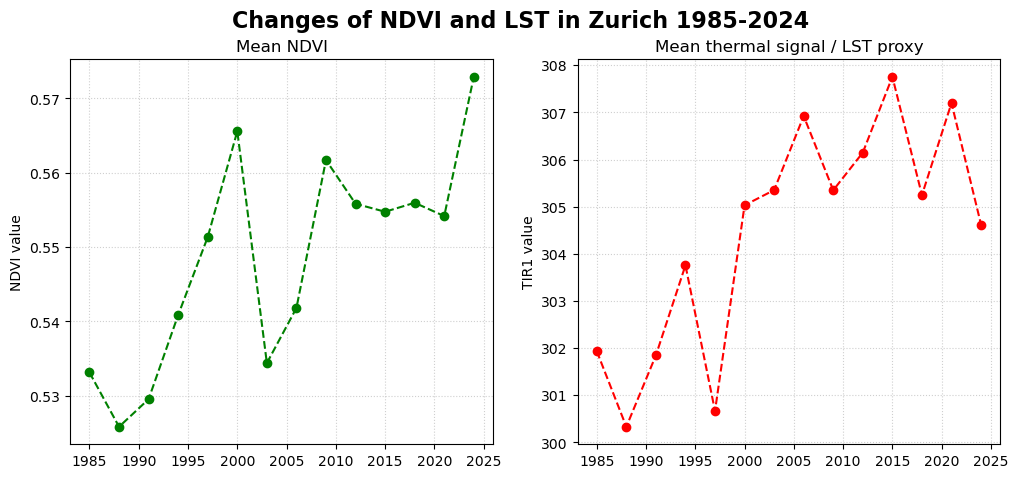

In [8]:
# Timeseries plot of the mean annual values for NDVI and the LST proxy (TIR1)
# Using subplots

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

# 1. plot showing the NDVI trend, 2. plot showing LST trend
axs[0].plot(df.year, df.mean_ndvi, color="green", marker="o", linestyle="--")
axs[1].plot(df.year, df.mean_lst, color="red", marker="o", linestyle="--")

axs[0].set_title("Mean NDVI")
axs[0].set_ylabel("NDVI value")
axs[0].grid(True, linestyle=":", alpha=0.6)

axs[1].set_title("Mean thermal signal / LST proxy")
axs[1].grid(True, linestyle=":", alpha=0.6)
axs[1].set_ylabel("TIR1 value")

fig.suptitle("Changes of NDVI and LST in Zurich 1985-2024", fontsize=16, fontweight="bold")

# Save Figure in a seperate folder figures/
fig.savefig("../figures/Trend_LST_NDVI.png", bbox_inches="tight")

plt.show()

Slope of trendline: 85.386
Intercept of trendline: 257.612


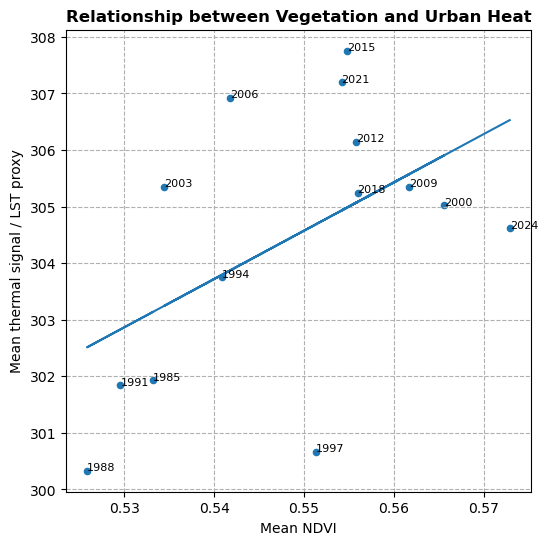

In [19]:
# Scatterplot to visualize if there is a possible relationship between NDVI and LST

df.plot.scatter(x="mean_ndvi", y="mean_lst", figsize=(6,6))

# Label all the points with the year using a for loop
for i in range(len(df)):

    plt.annotate(df["year"][i], (df["mean_ndvi"][i], df["mean_lst"][i]),
        fontsize=8)

# Add a trendline using np.polyfit
slope, intercept = np.polyfit(
    df["mean_ndvi"],
    df["mean_lst"],
    1)

# mean_ndvi = x
trendline = slope * df["mean_ndvi"] + intercept

plt.plot(
    df["mean_ndvi"],
    trendline)

# Print the values for slope and intercept
print(f"Slope of trendline: {slope:.3f}")
print(f"Intercept of trendline: {intercept:.3f}")

# Plot
plt.title("Relationship between Vegetation and Urban Heat", fontsize=12, fontweight="bold")
plt.xlabel("Mean NDVI")
plt.ylabel("Mean thermal signal / LST proxy")
plt.grid(linestyle="--")

plt.show()
# Save figure to the folder
fig.savefig("../figures/Relationship.png", bbox_inches="tight")



In [10]:
# Visually compare first and last date (1985 and 20249

# Fully the datasets
data_1985 = rioxarray.open_rasterio("../data/LandsatComposite_Zurich_1985.tif")
data_2024 = rioxarray.open_rasterio("../data/LandsatComposite_Zurich_2024.tif")

# Select the needed bands
red_1985 = data_1985.sel(band=3)
nir_1985 = data_1985.sel(band=4)
lst_1985 = data_1985.sel(band=7)

red_2024 = data_2024.sel(band=3)
nir_2024 = data_2024.sel(band=4)
lst_2024 = data_2024.sel(band=7)


# Filter red and nir bands 
red_1985 = red_1985.where(red >= 0)
nir_1985 = nir_1985.where(nir >= 0)

red_2024 = red_2024.where(red >= 0)
nir_2024 = nir_2024.where(nir >= 0)

# Calculate the NDVI values for both samples
ndvi_1985 = (nir_1985 - red_1985) / (nir_1985 + red_1985)
ndvi_2024 = (nir_2024 - red_2024) / (nir_2024 + red_2024)

In [11]:
# Check NDVI values if they are in the possible range

#print(ndvi_1985.min())
#print(ndvi_1985.max())

#print(ndvi_2024.min())
#print(ndvi_2024.max())

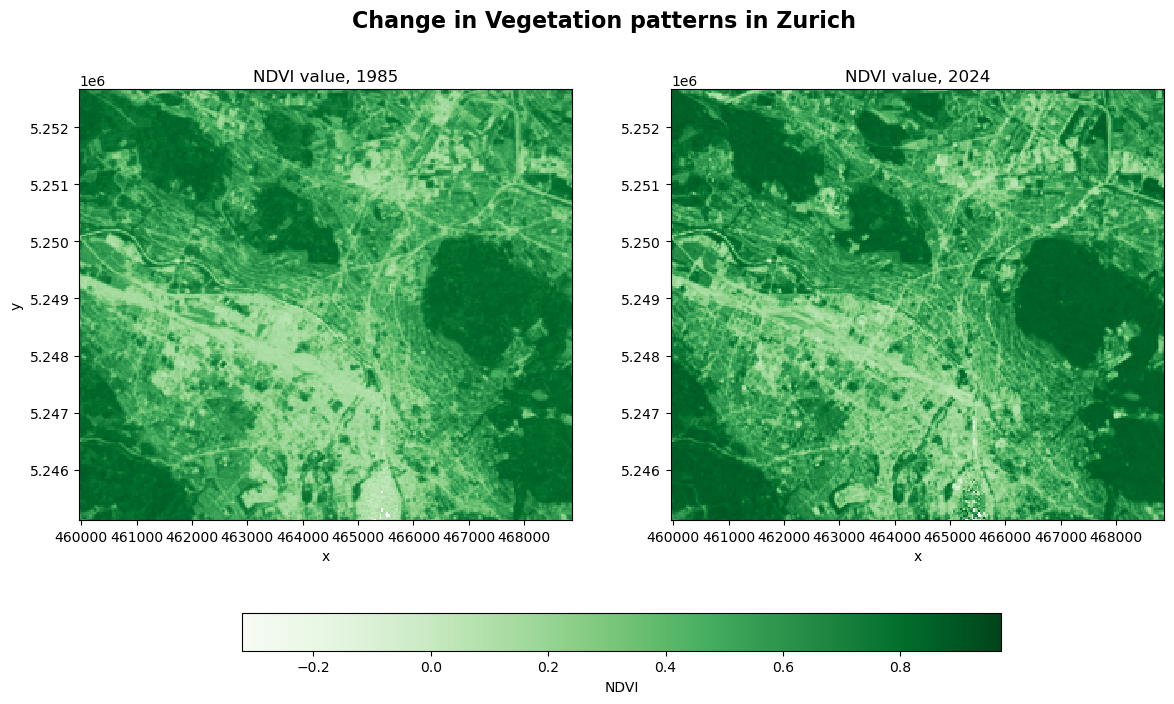

In [12]:
# Plot to visualize the NDVI pattens in Zurich 1985 and 2024
# Using a subplot with normalized colorbar for NDVI values so that both can be compared

# Find min and max values to later define boundaries for color (Vmin and vmax)
vmin_ndvi = min(float(ndvi_1985.min()), float(ndvi_2024.min()))
vmax_ndvi = max(float(ndvi_1985.max()), float(ndvi_2024.max()))

# Create subplot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14,8))

# Figure 1 1985
ndvi1 = ndvi_1985.plot(
    ax=ax[0],
    vmin=vmin_ndvi,
    vmax=vmax_ndvi,
    cmap="Greens",
    add_colorbar=False
)

# Figure 1 2024
ndvi2 = ndvi_2024.plot(
    ax=ax[1],
    vmin=vmin_ndvi,
    vmax=vmax_ndvi,
    cmap="Greens",
    add_colorbar=False
)

ax[0].set_title("NDVI value, 1985")
ax[1].set_title("NDVI value, 2024")

ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[1].set_xlabel("x")
ax[1].set_ylabel("")

# Add a shared colorbar
fig.colorbar(
    ndvi2,
    ax=ax,
    orientation = "horizontal",
    shrink=0.7,
    label="NDVI"
)
    
   
plt.suptitle("Change in Vegetation patterns in Zurich", fontsize=16, fontweight="bold")   

# Save figure
fig.savefig("../figures/Vegetation_patterns.png", bbox_inches="tight")

plt.show()

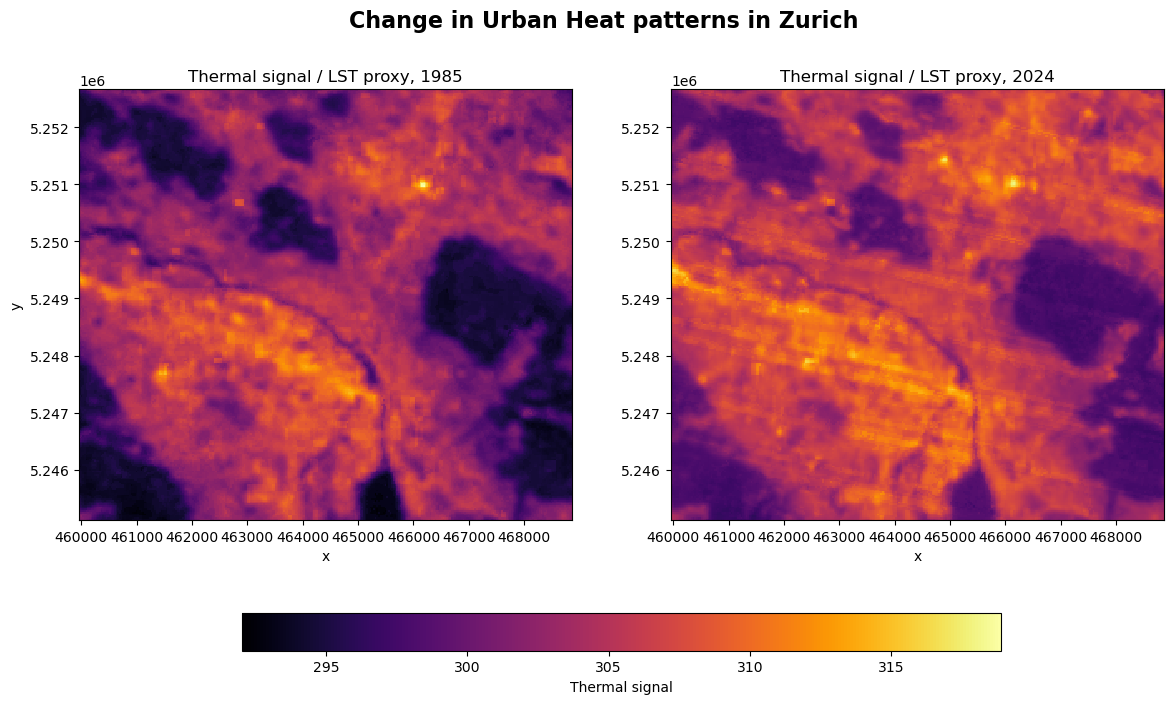

In [13]:
# Visualize Urban Heat patterns in Zurich 1985 and 2024
# Using subplots with a normalized colorbar for TIR1

# Identify max and min values
vmin_lst = min(float(lst_1985.min()), float(lst_2024.min()))
vmax_lst = max(float(lst_1985.max()), float(lst_2024.max()))

# Create figure
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14,8))

# Figure1 1985
lst1 = lst_1985.plot(
    ax=ax[0],
    vmin=vmin_lst,
    vmax=vmax_lst,
    cmap="inferno",
    add_colorbar=False
)

# Figure2 2024
lst2 = lst_2024.plot(
    ax=ax[1],
    vmin=vmin_lst,
    vmax=vmax_lst,
    cmap="inferno",
    add_colorbar=False
)


ax[0].set_title("Thermal signal / LST proxy, 1985")
ax[1].set_title("Thermal signal / LST proxy, 2024")

ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[1].set_xlabel("x")
ax[1].set_ylabel("")

# Add shared colorbar
fig.colorbar(
    lst2,
    ax=ax,
    orientation = "horizontal",
    shrink=0.7,
    label="Thermal signal"
)
    
   
plt.suptitle("Change in Urban Heat patterns in Zurich", fontsize=16, fontweight="bold")   

# Save figure
fig.savefig("../figures/Temperature_patterns", bbox_inches="tight")

plt.show()

In [14]:
# Create change masks that shows what areas have changed between 1985 and 2024

# Calculate change between the two years
ndvi_change = ndvi_2024 - ndvi_1985
lst_change = lst_2024 - lst_1985


#check min and max values

#print(ndvi_change.min())
#print(ndvi_change.max())

#print(lst_change.min())
#print(lst_change.max())

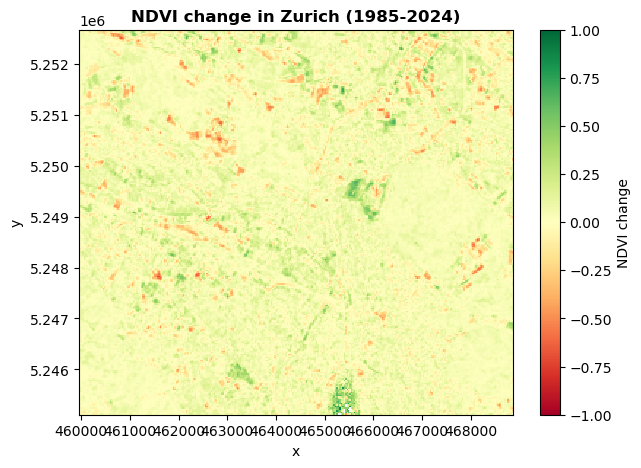

In [15]:
# Visualize the change in vegetation patterns between 1985 and 2024 (NDVI change mask) 

ndvi_change.plot(
    figsize=(7,5),
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    cbar_kwargs={
        "label": "NDVI change"
    })


plt.title("NDVI change in Zurich (1985-2024)",
         fontsize=12,
         fontweight="bold")

# Save figure
fig.savefig("../figures/NDVI_change.png", bbox_inches="tight")

plt.show()

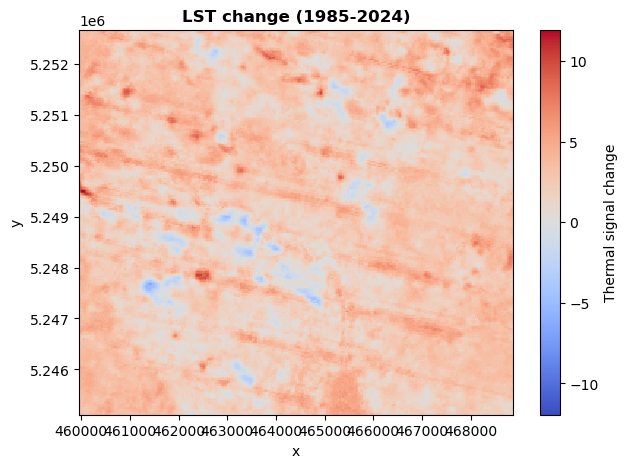

In [16]:
# Visualize the change in Urban Heat patterns between 1985 and 2024 (TIR1 change mask)
lst_change.plot(
    figsize=(7,5),
    cmap="coolwarm",
    cbar_kwargs={
        "label": "Thermal signal change"
    }
)
plt.title("LST change (1985-2024)",
         fontsize=12,
         fontweight="bold")

fig.savefig("../figures/LST_change", bbox_inches="tight")
plt.show()

In [17]:
# Print a summary of the mean change in NDVI and LST between 1985 and 2024

print("Summary:")

first_year = df.iloc[0]
last_year = df.iloc[-1]

ndvi_meanchange = last_year["mean_ndvi"] - first_year["mean_ndvi"]
print(f"Mean NDVI change from 1985 to 2024: {ndvi_meanchange:.4f}")

lst_meanchange = last_year["mean_lst"] - first_year["mean_lst"]
print(f"Mean LST change from 1985 to 2024: {lst_meanchange:.4f}")

Summary:
Mean NDVI change from 1985 to 2024: 0.0398
Mean LST change from 1985 to 2024: 2.6842
